# Differentiable Warp Regression

Tutorial notebook: **minimal synthetic example** showing the core warp module end-to-end (soft warp, dual likelihood, gradient training, holdout forecast).

### What is warp regression?

Many time series look like a **driver** (sine wave, input signal, trend) that has been **shifted in time** before being read out. Warp regression learns:

1. **A warp path** `p(i)` on sample **index** `i` — how far to slide the driver at each observation.
2. **A readout** that maps the warped driver to the target `y`.

Conceptually: `ŷ(i) = readout( soft_warp(driver, p)[i] )`.

### Dual likelihood (error + terror)

Training balances two terms controlled by **`fit_lambda = λ`**:

| Term | Meaning |
|------|---------|
| **Error NLL** (`obj_err`) | Gaussian fit of residuals — how well `ŷ` matches `y` |
| **Terror / path LL** (`obj_time`) | Random-walk prior on warp **offsets** `p(i)−i` — penalises jagged, implausible warps |

`loss = λ·obj_err − (1−λ)·obj_time`. Smaller `λ` trusts the path prior more; larger `λ` chases fit quality.

### Forecast uncertainty (three bands)

After fitting `σ_t` (path scale) and `σ_y` (observation noise):

- **Terror band (blue):** spread from many **stochastic warp paths** continued into the future (RW on offsets).
- **Error band (orange):** `ŷ_point ± 1.96·σ_y` — observation noise around the point forecast.
- **Combined band (purple):** union of both uncertainty sources (~95% coverage).

The **point forecast** freezes the warp offset at the train end and extrapolates the readout forward.

**Synthetic data** replicates [WarpPureNumpy.ipynb](https://github.com/aaron1rcl/warp_regression/blob/main/notebooks/WarpPureNumpy.ipynb) via `build_synthetic_dataset()`:

1. `np.random.seed(12)` → `x = sin(2π·(1:n)/100)` (unused `y2` draw advances RNG)
2. Gaussian shift increments, scale **10**, `truncate=False` → cumsum path `p`
3. Discrete warp (`matrix_decomp` → `X_shift` → `nanmedian` → downsample)
4. `y = warp(x) + N(0, 0.2)`

Defaults: **n = 300**, **sr = 10**. Trainable model: `ŷ = A·soft_warp(x, p) + C`.

**Holdout split:** train indices `0..199`, test `200..299` (100 steps). Steps 1–3 fit **train only**; step 4 forecasts the test window.

**Path:** `p[0]=0` fixed; identity mode `p[k]=k+offset[k]` with `offset[0]=0`. Terror LL uses offsets `p−k`.

**Training:** `fit_lambda=0.5` balances error vs path NLL.

**Evaluation:** MSE/corr on train; holdout metrics on test; dual objectives vs `NOTEBOOK_LL_TARGET` (full-series reference from `train_warp.py`).

In [1]:

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch

from warp_regression import (
    NOTEBOOK_LL_TARGET,
    WarpParametricModel,
    applied_path_offset_numpy,
    build_forecast_bands,
    build_synthetic_dataset,
    cumsum_path_to_stored_path,
    evaluate_model,
    per_index_rw_sigma,
    predict_forecast_realisations_torch,
    predict_realisations_torch,
    soft_warp_numpy,
    split_synthetic_holdout,
    stored_path_offset_numpy,
)

## Step 1: synthetic data & holdout split

`build_synthetic_dataset()` creates a sine driver warped by a random cumsum path, plus Gaussian noise. We hold out the last 100 indices to mimic Lynx/Bitcoin holdout evaluation.

/Users/ap/Desktop/warp/warp_regression/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


n=300  sr=10  scale=10.0  noise_std=0.2
Train indices 0–199 (n=200)  |  Test indices 200–299 (n=100)


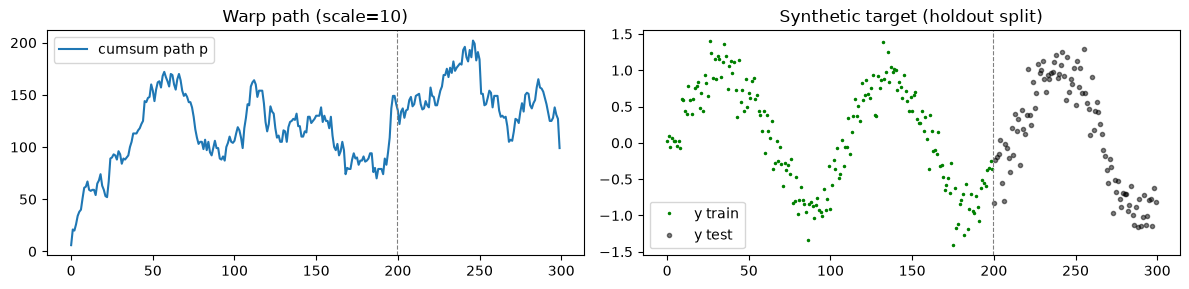

In [2]:
# Step 1: build synthetic driver x, hidden warp path, and noisy target y
data = build_synthetic_dataset()  # WarpPureNumpy.ipynb cells 4–8 (seed=12, n=300, scale=10)
print(f"n={data['n']}  sr={data['sr']}  scale={data['scale']}  noise_std={data['noise_std']}")

split = split_synthetic_holdout(data["n"], n_train=200)
train_idx, test_idx = split["train_idx"], split["test_idx"]
n_train, n_test = split["n_train"], split["n_test"]
print(f"Train indices 0–{n_train - 1} (n={n_train})  |  Test indices {n_train}–{data['n'] - 1} (n={n_test})")

x_train = torch.tensor(data["x"][train_idx], dtype=torch.float32)
y_train = torch.tensor(data["y"][train_idx], dtype=torch.float32)
sr = data["sr"]

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(data["p_true"], label="cumsum path p")
axes[0].axvline(n_train - 0.5, color="gray", ls="--", lw=0.8)
axes[0].set_title("Warp path (scale=10)")
axes[0].legend()
axes[1].plot(train_idx, data["y"][train_idx], "g.", ms=3, label="y train")
axes[1].plot(test_idx, data["y"][test_idx], "ko", ms=3, alpha=0.5, label="y test")
axes[1].axvline(n_train - 0.5, color="gray", ls="--", lw=0.8)
axes[1].set_title("Synthetic target (holdout split)")
axes[1].legend()
fig.tight_layout()
plt.show()

## Step 2: train the parametric warp model (train only)

`WarpParametricModel` stores B-spline knot values for `p`, learnable amplitude `A`, bias `C`, and log-scales `σ_t`, `σ_y`. Training minimises the dual loss with `fit_lambda=0.5`.

Run `python train_warp.py` separately for the full-series reference checkpoint.

In [3]:
# Step 2: fit WarpParametricModel on train split (λ=0.5, Adam)
# ŷ = A·soft_warp(x, p) + C; knots in p learned jointly with A, C, σ_t, σ_y
from pathlib import Path
ckpt = Path("outputs") / "model.pt"
model = WarpParametricModel(n=n_train, n_knots=8, sr=sr, A_init=1.0, C_init=0.0)

print("Training on train split only (or run: python train_warp.py for full-series ref)")
model.fit(x_train, y_train, epochs=5000, lr=0.03, seed=0, fit_lambda=0.5)
ckpt.parent.mkdir(parents=True, exist_ok=True)
torch.save(model.state_dict(), ckpt)

with torch.no_grad():
    sigma_t = float(torch.exp(model.log_sigma_t))
    p_fit = model.path().numpy()
    off_apply = applied_path_offset_numpy(p_fit)
report = evaluate_model(model, x_train, y_train, use_discrete_warp=True, n=n_train, sr=sr)
print(f"sigma_t={sigma_t:.4f}  per_index_rw_sigma={per_index_rw_sigma(sigma_t, n_train, model.n_knots):.4f}")
print(f"offset_apply step std={np.std(np.diff(off_apply)):.4f}")
print(f"Train report: {report}")
print(f"Full-series LL reference (train_warp.py): {NOTEBOOK_LL_TARGET}")

Training on train split only (or run: python train_warp.py for full-series ref)


sigma_t=0.1932  per_index_rw_sigma=1.0300
offset_apply step std=0.1922
Train report: EvalReport(mse=0.046427346765995026, rmse=0.215470060022257, corr=0.9507939762227019, obj_err=-23.198936462402344, obj_time=3.8834214210510254, err_nll=23.198936462402344, time_ll=-3.8834214210510254, ll_distance=589.1843554883651, discrete_mse=0.059540393975673366)
Full-series LL reference (train_warp.py): (283.71669407633806, 506.8158229257141)


## Step 3: path diagnostics & train-window uncertainty

Compare the learned warp path to the synthetic ground truth. Offsets `p(i)−i` are what the terror LL regularises. Path **realisations** show how RW uncertainty grows along the train window.

Path anchor: p[0]=0 fixed
  p_learned[0]=-4.493  p_learned[-1]=199.0  offset[-1]=0.00
  soft_warp(x, p_ref) vs y_train corr = 0.268
  learned p vs cumsum-anchored corr = 0.994


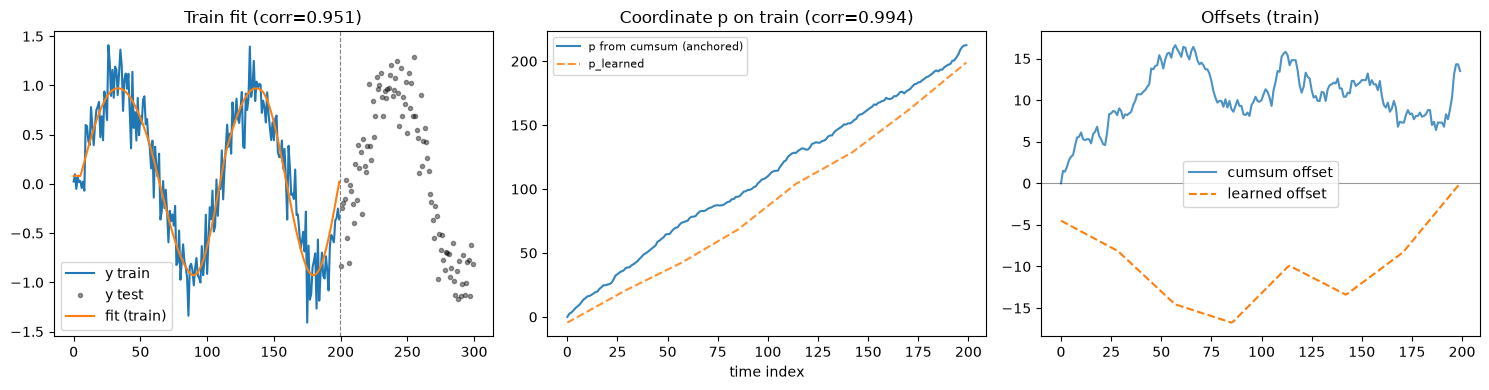

In [4]:
# Step 3: compare learned path p to ground-truth cumsum path
with torch.no_grad():
    d = model.losses(x_train, y_train, torch.tensor(0.5))
    y_fit = d["y_hat"].numpy()
    p_fit = d["p"].numpy()

p_true = data["p_true"][:n_train]
p_ref = cumsum_path_to_stored_path(data["p_true"], data["n"], sr)[:n_train]
x_np = data["x"][:n_train]
idx = np.arange(n_train, dtype=float)

off_fit = stored_path_offset_numpy(p_fit)
off_ref = stored_path_offset_numpy(p_ref)
warp_ref = soft_warp_numpy(x_np, p_ref, reverse_path=False)
print("Path anchor: p[0]=0 fixed")
print(f"  p_learned[0]={p_fit[0]:.3f}  p_learned[-1]={p_fit[-1]:.1f}  offset[-1]={off_fit[-1]:.2f}")
print(f"  soft_warp(x, p_ref) vs y_train corr = {np.corrcoef(warp_ref, y_train.numpy())[0,1]:.3f}")
print(f"  learned p vs cumsum-anchored corr = {np.corrcoef(p_ref, p_fit)[0,1]:.3f}")

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(train_idx, y_train.numpy(), label="y train")
ax[0].plot(test_idx, data["y"][test_idx], "ko", ms=3, alpha=0.4, label="y test")
ax[0].plot(y_fit, label="fit (train)")
ax[0].axvline(n_train - 0.5, color="gray", ls="--", lw=0.8)
ax[0].legend()
ax[0].set_title(f"Train fit (corr={report.corr:.3f})")

ax[1].plot(p_ref, label="p from cumsum (anchored)", alpha=0.9)
ax[1].plot(p_fit, linestyle="--", label="p_learned", alpha=0.85)
ax[1].legend(fontsize=8)
ax[1].set_title(f"Coordinate p on train (corr={np.corrcoef(p_ref, p_fit)[0,1]:.3f})")
ax[1].set_xlabel("time index")

ax[2].plot(off_ref, label="cumsum offset", alpha=0.8)
ax[2].plot(off_fit, linestyle="--", label="learned offset")
ax[2].axhline(0, color="k", linewidth=0.8, alpha=0.4)
ax[2].legend()
ax[2].set_title("Offsets (train)")
plt.tight_layout()
plt.show()

/var/folders/5s/p4grnv4s5k17kjk3xgp7qpmh0000gn/T/ipykernel_91889/4228936415.py:16: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:839.)
  sigma_t = float(torch.exp(model.log_sigma_t))


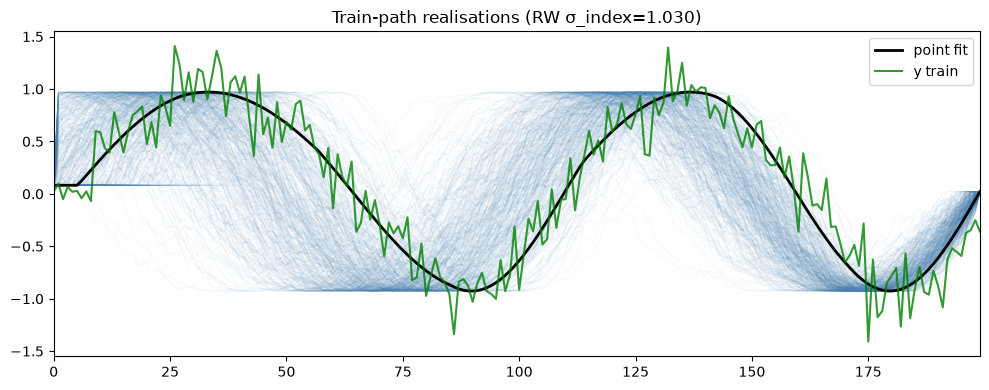

paths shape (400, 200)  std[0]=0.0000  std[199]=0.0000


In [5]:
# Step 3b: sample train-window path uncertainty (RW continuation from fitted p)
h = n_train
n_draws = 400
paths = predict_realisations_torch(model, x_train, n_draws=n_draws, horizon=h)

with torch.no_grad():
    y_fit = model.predict(x_train).numpy()

fig, ax = plt.subplots(figsize=(10, 4))
for k in range(paths.shape[0]):
    ax.plot(paths[k], color="steelblue", alpha=0.06, linewidth=0.7)
ax.plot(y_fit, color="black", linewidth=2, label="point fit")
ax.plot(y_train.numpy(), color="green", linewidth=1.5, alpha=0.8, label="y train")
ax.set_xlim(0, h - 1)
ax.legend()
sigma_t = float(torch.exp(model.log_sigma_t))
sigma_step = per_index_rw_sigma(sigma_t, n_train, model.n_knots)
ax.set_title(f"Train-path realisations (RW σ_index={sigma_step:.3f})")
fig.tight_layout()
plt.show()

print(f"paths shape {paths.shape}  std[0]={paths[:, 0].std():.4f}  std[{h-1}]={paths[:, -1].std():.4f}")

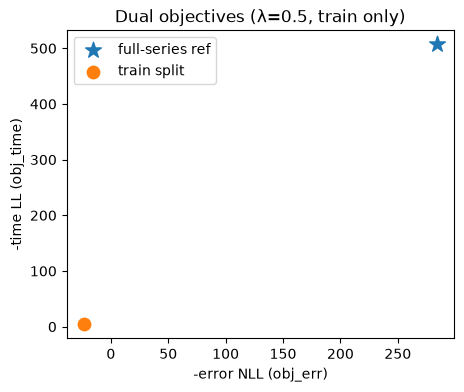

In [6]:
# Step 3c: dual-objective scatter — error NLL vs terror LL (train split vs full-series ref)
plt.figure(figsize=(5, 4))
plt.scatter([NOTEBOOK_LL_TARGET[0]], [NOTEBOOK_LL_TARGET[1]], s=140, marker="*", label="full-series ref")
plt.scatter([report.obj_err], [report.obj_time], s=80, label="train split")
plt.xlabel("-error NLL (obj_err)")
plt.ylabel("-time LL (obj_time)")
plt.legend()
plt.title("Dual objectives (λ=0.5, train only)")
plt.show()

## Step 4: holdout forecast — terror + error + combined 95% bands

Extend warp paths into the test window with per-index RW steps (`σ_index = σ_t·√rw`). Each path gives a forecast; `build_forecast_bands` forms terror, error, and combined envelopes around the **point forecast** (warp offset frozen at train end).

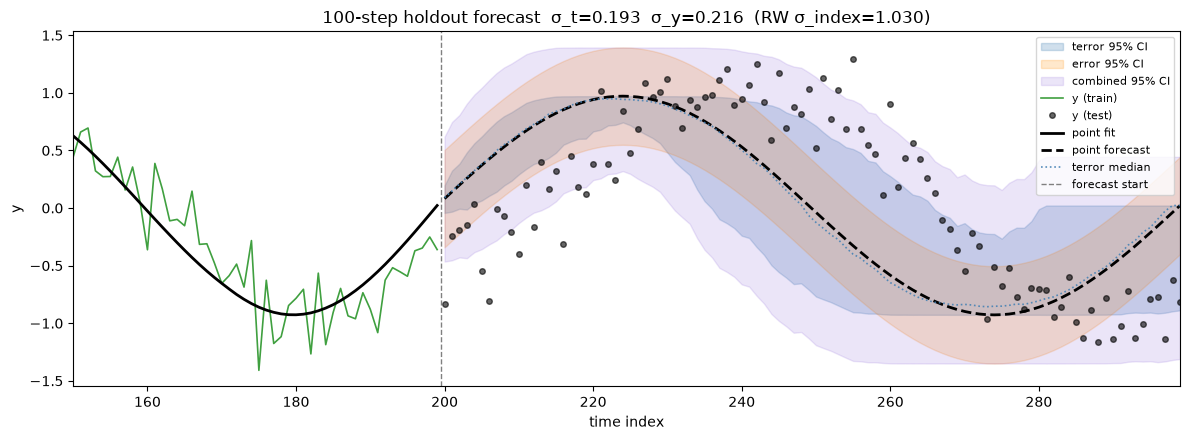

test corr (point) = 0.548
test RMSE = 0.6804
test in combined 95% band: 86%
terror  band width at test start/end: 0.2387 / 0.9099
error   band width at test start/end: 0.8449 / 0.8449
combined band width at test start/end: 1.0837 / 1.7549


In [7]:
# Step 4: holdout forecast on test window — terror + error + combined 95% bands
n_future = n_test
n_context = 50
n_draws_ci = 400

fc = predict_forecast_realisations_torch(model, x_train, n_future=n_future, n_draws=n_draws_ci, seed=1)
bands = fc["bands"]
n_total = fc["n_total"]
sigma_y = fc["sigma_y"]
sigma_t = fc["sigma_t"]
y_point = fc["y_point"]
y_test = data["y"][test_idx]

t_q_lo, t_q50, t_q_hi = bands["t_q_lo"], bands["t_q50"], bands["t_q_hi"]
err_lo, err_hi = bands["err_lo"], bands["err_hi"]
c_q_lo, c_q_hi = bands["c_q_lo"], bands["c_q_hi"]

plot_start = max(0, n_train - n_context)
t_idx = np.arange(plot_start, n_total)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.fill_between(t_idx[t_idx >= n_train], t_q_lo[n_train:], t_q_hi[n_train:], color="steelblue", alpha=0.25, label="terror 95% CI")
ax.fill_between(t_idx[t_idx >= n_train], err_lo[n_train:], err_hi[n_train:], color="darkorange", alpha=0.2, label="error 95% CI")
ax.fill_between(t_idx[t_idx >= n_train], c_q_lo[n_train:], c_q_hi[n_train:], color="mediumpurple", alpha=0.18, label="combined 95% CI")
ax.plot(t_idx[t_idx < n_train], data["y"][plot_start:n_train], color="green", linewidth=1.2, alpha=0.75, label="y (train)")
ax.plot(test_idx, y_test, "ko", ms=4, alpha=0.6, label="y (test)")
ax.plot(t_idx[t_idx < n_train], y_point[plot_start:n_train], color="black", linewidth=2, label="point fit")
ax.plot(test_idx, y_point[test_idx], color="black", linewidth=2, linestyle="--", label="point forecast")
ax.plot(test_idx, t_q50[test_idx], color="steelblue", linewidth=1.2, linestyle=":", alpha=0.9, label="terror median")
ax.axvline(n_train - 0.5, color="gray", linestyle="--", linewidth=1, label="forecast start")
ax.set_xlim(plot_start, n_total - 1)
ax.set_xlabel("time index")
ax.set_ylabel("y")
ax.set_title(
    f"{n_future}-step holdout forecast  σ_t={sigma_t:.3f}  σ_y={sigma_y:.3f}  "
    f"(RW σ_index={per_index_rw_sigma(sigma_t, n_train, model.n_knots):.3f})"
)
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()

f0, f1 = test_idx[0], test_idx[-1]
in_combined = (y_test >= c_q_lo[test_idx]) & (y_test <= c_q_hi[test_idx])
print(f"test corr (point) = {np.corrcoef(y_point[test_idx], y_test)[0,1]:.3f}")
print(f"test RMSE = {np.sqrt(np.mean((y_point[test_idx] - y_test)**2)):.4f}")
print(f"test in combined 95% band: {in_combined.mean()*100:.0f}%")
print(f"terror  band width at test start/end: {(t_q_hi[f0]-t_q_lo[f0]):.4f} / {(t_q_hi[f1]-t_q_lo[f1]):.4f}")
print(f"error   band width at test start/end: {(err_hi[f0]-err_lo[f0]):.4f} / {(err_hi[f1]-err_lo[f1]):.4f}")
print(f"combined band width at test start/end: {(c_q_hi[f0]-c_q_lo[f0]):.4f} / {(c_q_hi[f1]-c_q_lo[f1]):.4f}")

## Summary

| Step | What happens |
|------|----------------|
| 1 | Synthetic sine + cumsum warp + noise; train/test split |
| 2 | Fit `WarpParametricModel` on train (`λ=0.5`) |
| 3 | Path vs truth, train realisations, dual-objective scatter |
| 4 | 100-step holdout forecast with terror / error / combined 95% bands |